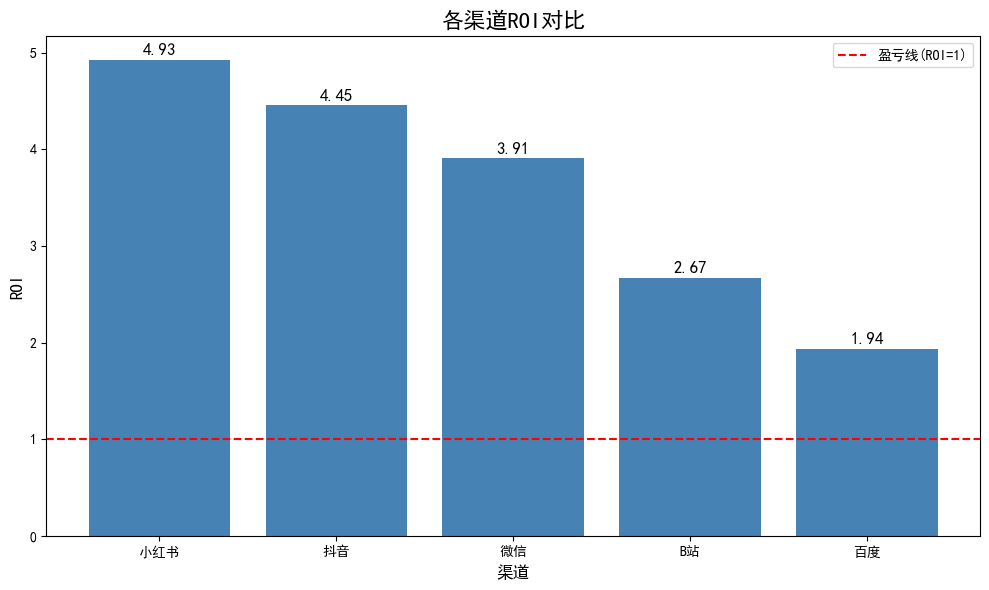

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 解决中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 加载汇总数据
summary = pd.read_csv('../data/cleaned/channel_summary.csv')

# 按ROI排序
summary = summary.sort_values('ROI', ascending=False)

# 画柱状图
plt.figure(figsize=(10, 6))
plt.bar(summary['渠道'], summary['ROI'], color='steelblue')

# 加数值标签
for i, v in enumerate(summary['ROI']):
    plt.text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=12)

plt.title('各渠道ROI对比', fontsize=16)
plt.xlabel('渠道', fontsize=12)
plt.ylabel('ROI', fontsize=12)
plt.axhline(y=1, color='red', linestyle='--', label='盈亏线(ROI=1)')
plt.legend()
plt.tight_layout()

# 保存
plt.savefig('../output/charts/01_渠道ROI对比.png', dpi=150, bbox_inches='tight')
plt.show()

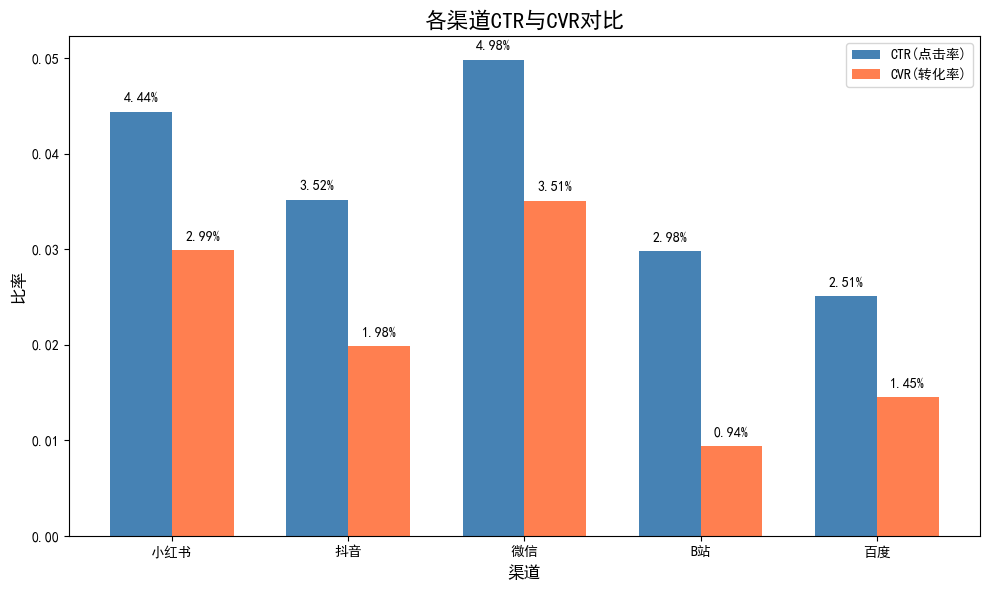

In [3]:
# 按ROI排序（保持一致）
summary = summary.sort_values('ROI', ascending=False)

# 准备数据
x = range(len(summary))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# 画两根柱子
bars1 = ax.bar([i - width/2 for i in x], summary['CTR'], width, label='CTR(点击率)', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], summary['CVR'], width, label='CVR(转化率)', color='coral')

# 加数值标签
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.001,
                f'{height:.2%}', ha='center', fontsize=10)

ax.set_title('各渠道CTR与CVR对比', fontsize=16)
ax.set_xlabel('渠道', fontsize=12)
ax.set_ylabel('比率', fontsize=12)
ax.set_xticks(list(x))
ax.set_xticklabels(summary['渠道'])
ax.legend()
plt.tight_layout()

plt.savefig('../output/charts/02_渠道CTR_CVR对比.png', dpi=150, bbox_inches='tight')
plt.show()

各渠道漏斗转化率：
 渠道     曝光量    点击量  转化量      点击率      转化率    整体转化率
小红书 4530477 201132 6011 0.044395 0.029886 0.001327
 抖音 7321759 257506 5111 0.035170 0.019848 0.000698
 微信 3657939 182248 6391 0.049823 0.035068 0.001747
 B站 2773837  82565  776 0.029766 0.009399 0.000280
 百度 5438661 136445 1983 0.025088 0.014533 0.000365


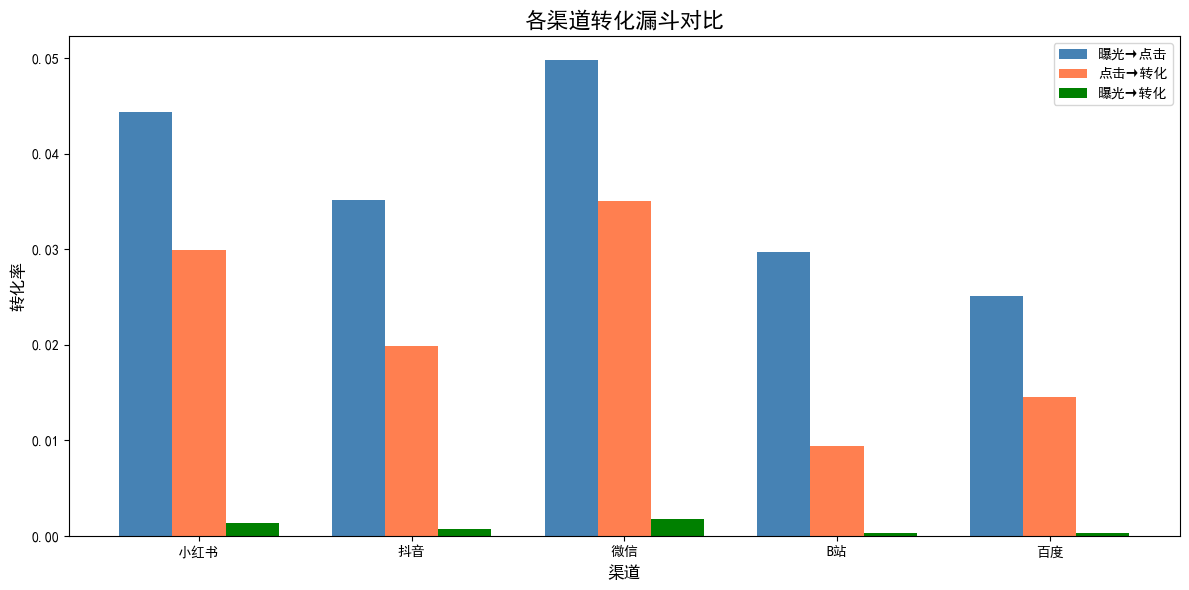

In [4]:
# 计算各渠道的漏斗转化率
funnel = summary[['渠道', '曝光量', '点击量', '转化量']].copy()
funnel['点击率'] = funnel['点击量'] / funnel['曝光量']
funnel['转化率'] = funnel['转化量'] / funnel['点击量']
funnel['整体转化率'] = funnel['转化量'] / funnel['曝光量']

print("各渠道漏斗转化率：")
print(funnel.to_string(index=False))

# 画分组柱状图
x = range(len(funnel))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar([i - width for i in x], funnel['点击率'], width, label='曝光→点击', color='steelblue')
ax.bar(list(x), funnel['转化率'], width, label='点击→转化', color='coral')
ax.bar([i + width for i in x], funnel['整体转化率'], width, label='曝光→转化', color='green')

ax.set_title('各渠道转化漏斗对比', fontsize=16)
ax.set_xlabel('渠道', fontsize=12)
ax.set_ylabel('转化率', fontsize=12)
ax.set_xticks(list(x))
ax.set_xticklabels(funnel['渠道'])
ax.legend()
plt.tight_layout()

plt.savefig('../output/charts/03_渠道转化漏斗.png', dpi=150, bbox_inches='tight')
plt.show()

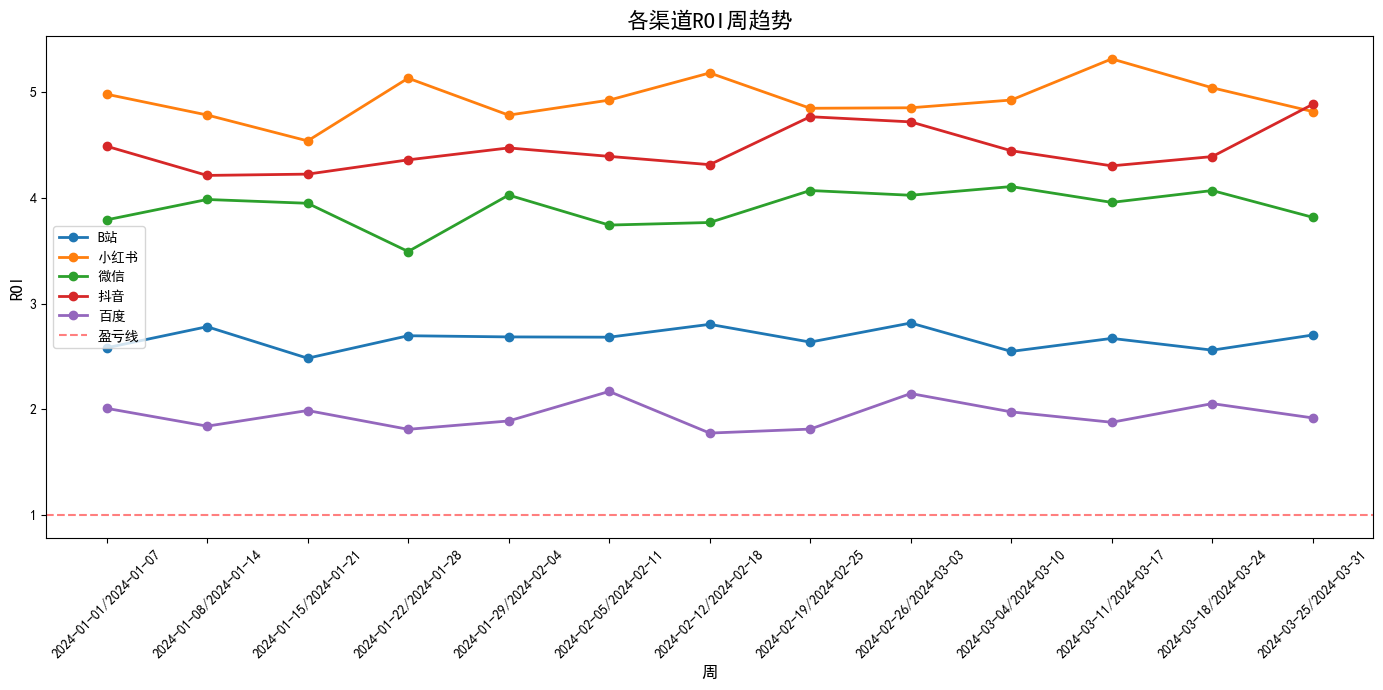

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 加载清洗数据
df = pd.read_csv('../data/cleaned/channel_clean.csv')
df['日期'] = pd.to_datetime(df['日期'])

# 按周汇总（W表示周）
df['周'] = df['日期'].dt.to_period('W').astype(str)

# 按周+渠道汇总
weekly = df.groupby(['周', '渠道']).agg({
    '花费': 'sum',
    '收入': 'sum'
}).reset_index()

# 算每周ROI
weekly['ROI'] = weekly['收入'] / weekly['花费']

# 画折线图
fig, ax = plt.subplots(figsize=(14, 7))

for ch in weekly['渠道'].unique():
    data = weekly[weekly['渠道'] == ch]
    ax.plot(data['周'], data['ROI'], marker='o', label=ch, linewidth=2)

ax.set_title('各渠道ROI周趋势', fontsize=16)
ax.set_xlabel('周', fontsize=12)
ax.set_ylabel('ROI', fontsize=12)
ax.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='盈亏线')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('../output/charts/04_渠道ROI趋势.png', dpi=150, bbox_inches='tight')
plt.show()

# 渠道效果分析结论

## 一、整体表现

按ROI从高到低：小红书(4.93) > 抖音(4.45) > 微信(3.91) > B站(2.67) > 百度(1.94)

所有渠道ROI均大于1，整体投放健康。

## 二、分渠道结论与建议

### 1. 小红书 —— 加预算
- **现象**：ROI最高(4.93)，CTR(4.44%)、CVR(2.99%)均中上
- **原因**：用户群体与产品匹配度高
- **建议**：**加大投放预算**，优先扩量

### 2. 微信 —— 优化成本
- **现象**：CTR(4.98%)、CVR(3.51%)双第一，但ROI仅第三(3.91)
- **原因**：CPC最贵(1.79元)，花费高
- **建议**：**不砍，优化成本**——测试低价投放方式

### 3. 抖音 —— 维持观察
- **现象**：曝光最大，ROI第二(4.45)，但**周波动最大**
- **原因**：投放不稳定
- **建议**：**维持，观察波动原因**，稳定后可加量

### 4. B站 —— 优化转化
- **现象**：CVR最低(0.94%)，卡在"点击→转化"
- **原因**：落地页或选品与B站用户不匹配
- **建议**：**优化落地页/选品**，先别加预算

### 5. 百度 —— 削减或转型
- **现象**：CTR最低(2.51%)，ROI最低(1.94)
- **原因**：广告素材不吸引人，转化也差
- **建议**：**削减预算**，或换素材/换人群重测

## 三、预算调整预测

**假设**：总预算不变，将百度50%预算（10.2万）转移至小红书

**测算**：
- 调整前整体ROI：3.81
- 调整后整体ROI：4.10
- 预计提升：约7.6%

**前提与风险**：
- 假设各渠道ROI维持当前水平
- 实际执行中，小红书预算增加后ROI可能下降（边际效应递减）
- 建议分批加量、持续监控

## 四、整体建议

1. **加预算**：小红书
2. **优化成本**：微信
3. **优化转化**：B站
4. **削减/转型**：百度
5. **维持观察**：抖音

## 五、下一步行动

1. **小红书**：分批加量，第一阶段预算+20%，观察2周ROI；
   若稳定，逐步追加，最终承接百度削减的10.2万预算
2. **微信**：测试低价投放方式，目标CPC降到1.5元
3. **百度**：预算砍半，剩余预算测试新素材
4. **B站**：暂停加量，先优化落地页